# NYS Donate Life

### Reseach Question

How can New York State identify and prioritize communities at risk of low organ donor registration to support equity-centered outreach and resource allocation?

#### Dataset
https://health.data.ny.gov/Health/New-York-State-Donate-Life-Registry-Enrollment-by-/gvq6-s8vf/about_data

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
# donate_df = pd.read_csv('New_York_State_Donate_Life_Registry_Enrollment_by_Zip_Code_20260228.csv', low_memory=False)
# donate_df.head()

# 1️⃣ `donate_df`
- num rows = 159,711 (one row per month, per year, per zip code)
- column = 4
    - `Zip Code` unique = 🙋🏻‍♀️ 1331?
    - `Year` range: 2008 - 2026 (18 years)
    - `Month`range: 1-12
    - `Registry Enrollments` range: 10 – 1,104

- aggregate all months of year by zipcode to see trends over years 2008-2026
- see which zip codes de/increased enrollment over time

In [118]:
donate_df.describe()

,Zip Code,Year,Month
count,159711.000000,159711.000000,159711.000000
mean,12331.583642,2016.707190,6.562666
std,1442.246555,4.995214,3.416615
min,7310.000000,2008.000000,1.000000
25%,11218.000000,2012.000000,4.000000
50%,12053.000000,2017.000000,7.000000
75%,13619.000000,2021.000000,10.000000
max,14905.000000,2026.000000,12.000000


In [121]:
donate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159711 entries, 0 to 159710
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Zip Code              159711 non-null  int64 
 1   Year                  159711 non-null  int64 
 2   Month                 159711 non-null  int64 
 3   Registry Enrollments  159711 non-null  object
dtypes: int64(3), object(1)
memory usage: 4.9+ MB


In [112]:
donate_df.nunique()

Zip Code                1331
Year                      19
Month                     12
Registry Enrollments     425
dtype: int64

In [76]:
# convert `Registry Enrollments` col into a float
# donate_df["Registry Enrollments"] = pd.to_numeric(donate_df["Registry Enrollments"], downcast="float")

In [122]:
# show error with comma preventing dtype conversion
donate_df.loc[4946]

Zip Code                10021
Year                     2009
Month                       5
Registry Enrollments    1,104
Name: 4946, dtype: object

In [126]:
# replace all commas in `Registry Enrollments` col with nothing
donate_df['Registry Enrollments'] = donate_df['Registry Enrollments'].str.replace(',', '')

In [127]:
# show row again to verify comma is removed
donate_df.loc[4946]

Zip Code                10021
Year                     2009
Month                       5
Registry Enrollments     1104
Name: 4946, dtype: object

In [128]:
# attempt 2: convert `Registry Enrollments` col into a float
donate_df["Registry Enrollments"] = pd.to_numeric(donate_df["Registry Enrollments"], downcast="float")

In [129]:
# verify dtypes
donate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159711 entries, 0 to 159710
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Zip Code              159711 non-null  int64  
 1   Year                  159711 non-null  int64  
 2   Month                 159711 non-null  int64  
 3   Registry Enrollments  159711 non-null  float32
dtypes: float32(1), int64(3)
memory usage: 4.3 MB


In [130]:
donate_df.describe()

,Zip Code,Year,Month,Registry Enrollments
count,159711.000000,159711.000000,159711.000000,159711.000000
mean,12331.583642,2016.707190,6.562666,42.653755
std,1442.246555,4.995214,3.416615,40.572071
min,7310.000000,2008.000000,1.000000,10.000000
25%,11218.000000,2012.000000,4.000000,17.000000
50%,12053.000000,2017.000000,7.000000,29.000000
75%,13619.000000,2021.000000,10.000000,53.000000
max,14905.000000,2026.000000,12.000000,1104.000000


@ first glance: (1) zip codes with high enrolment per month & year are in Manhattan 10021 UES, 10025 UWS/Morningside Heights, 10024 UWS, 10023 UWS; (2) only 1 in Brooklyn 11215. 
- What would aggregate data show?
  

# 2️⃣ `yearly_df`
- num rows = 18,230 (one row per zip code per year)
- cols = 3
    - `Zip Code` range: 7310 - 14905 (looks like a typo with min zip code)
    - `Year` range: 2008 - 2026 (18 years)
    - `Registry Enrollments` range: 10 – 4,063

In [90]:
# aggregate data by month & year

yearly_df = (
    donate_df
    .groupby(["Zip Code", "Year"], as_index=False)
    .agg({
        "Registry Enrollments": "sum"
    })
)

In [108]:
yearly_df.head(3).sort_values('Year', ascending=True )

,Zip Code,Year,Registry Enrollments
1,10001,2008,167.0
2,10001,2009,709.0
0,7310,2016,10.0


In [113]:
yearly_df.describe()

,Zip Code,Year,Registry Enrollments
count,18230.000000,18230.000000,18230.000000
mean,12490.679759,2016.521503,373.684814
std,1419.360124,5.151046,436.441956
min,7310.000000,2008.000000,10.000000
25%,11368.000000,2012.000000,70.000000
50%,12443.000000,2017.000000,231.000000
75%,13743.000000,2021.000000,507.000000
max,14905.000000,2026.000000,4063.000000


In [114]:
yearly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18230 entries, 0 to 18229
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Zip Code              18230 non-null  int64  
 1   Year                  18230 non-null  int64  
 2   Registry Enrollments  18230 non-null  float32
dtypes: float32(1), int64(2)
memory usage: 356.2 KB


# 3️⃣ `yearly_totals`
- num rows = 18 (one row per year)
- cols = 2
    - `Year` range: 2008 – 2026 (18 years)
    - `Registry Enrollments` range: 26 - 576,909

In [96]:
# see data in table format

yearly_totals = (
    yearly_df
    .groupby("Year", as_index=False)
    .agg({"Registry Enrollments": "sum"})
    .sort_values("Year")
)
yearly_totals

,Year,Registry Enrollments
0,2008,62797.0
1,2009,453728.0
2,2010,449287.0
3,2011,486162.0
4,2012,499021.0
5,2013,280256.0
6,2014,230767.0
7,2015,324444.0
8,2016,403212.0
9,2017,576909.0


In [111]:
yearly_totals.describe()

,Year,Registry Enrollments
count,19.000000,19.00000
mean,2017.000000,358540.75000
std,5.627314,155961.84375
min,2008.000000,96.00000
25%,2012.500000,298627.50000
50%,2017.000000,342261.00000
75%,2021.500000,469945.00000
max,2026.000000,576909.00000


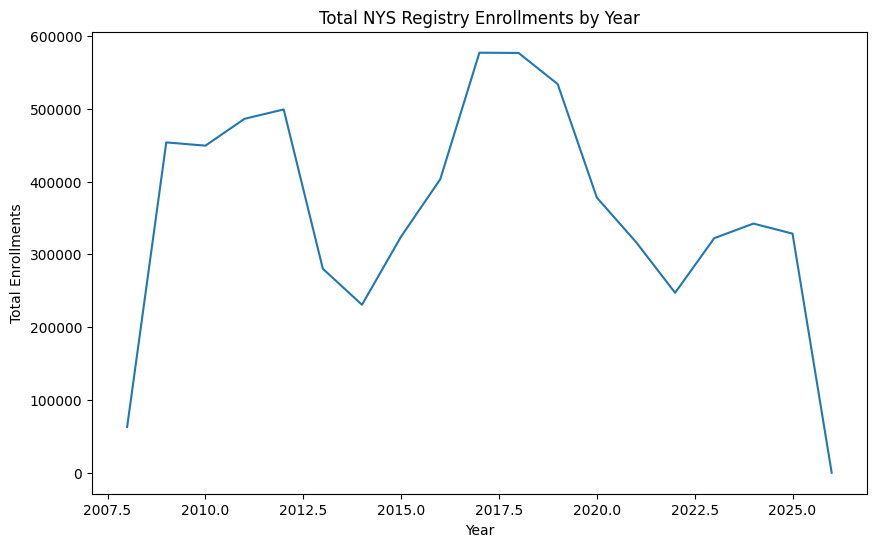

In [97]:
# double check visuzliation using `yearly_totals_df`

plt.figure(figsize=(10,6))

sns.lineplot(
    data=yearly_totals,
    x="Year",
    y="Registry Enrollments"
)

plt.title("Total NYS Registry Enrollments by Year")
plt.xlabel("Year")
plt.ylabel("Total Enrollments")
plt.show()